# Face-inversion regressor ↔ video alignment (a stimulus EDA)

### OUTCOME: Seems like some of the T1 values don't quite match up the video and eeg files well enough (ex. 3, 4, 6), may need write our own T1 triggers
### This could be done manually i.e. find when in eeg samples the first face stimulus appears from the video, then find the delta (DELTA 1) between the current timestamp and the start of the video, then calculate how long this would be roughly in eeg signals. Finally, take DELTA 1 (eeg samples) from the delta (DELTA 2) of current eeg sample (first face stimulus) - This should give new T1 (this asumes the M1 triggers themselves are spaced out correctly too i.e. no time drift or timeline mismatch)



The Face+Mobile task (Krugliak & Clarke, *Scientific Reports*) gives
each subject a head-cam video plus a preprocessed EEG file, `RmIaf_mobileface.set/fdt`. The authors
stored a **face-inversion regressor** as an extra channel in that file: a per-event label marking
each moment a face appeared as **upright** (`UP`) or **upside-down / inverted** (`IN`). Those events
are timed in **EEG samples**. To recover *what the camera was actually looking at*, at each event
the pixels a vision model (or a human) would see, we have to shift every event out of EEG time and
into **video time**.

That shift is a single subtraction. The video starts *after* EEG recording begins, and a trigger
(`T 1` in each subject's `Triggers.xlsx`) marks the video-start sample. So for a face event at EEG
time `onset`, the corresponding video time is:

```
t_video = onset − t1          # t1 = T 1 video-start, in EEG seconds
```

Grab the frame at `t_video` and, if the alignment is right, it should show a face at the labelled
orientation. **It doesn't always.** In the stimulus-check grid of `cornet_full_run.ipynb` this lands
cleanly for some subjects (e.g. **sub3** — nearly every grabbed frame is a clear, correctly-oriented
face) but badly for others (**subs 1, 4, 5, 7, 8** — many grabbed frames contain no detectable face
at all, or the wrong content entirely). You can see it by eye, and the face detector confirms it: a
large fraction of "face" events resolve to *no-face* frames.

**The question this notebook investigates.** Is that misalignment real, and where does it come from?
The mapping has only a few moving parts, and each is a per-subject quantity that could be wrong:

- **`t1` (the `T 1` video-start trigger)** — read from `Triggers.xlsx`. A wrong or mis-picked `T 1`
  shifts *every* event by a constant offset, so faces land systematically early or late.
- **the video's `fps` / duration** — used to convert `t_video` (seconds) into a frame index. A wrong
  frame rate makes the error grow across the video (fine at the start, drifting by the end).
- **the events themselves** — the `UP`/`IN` annotations carried in `RmIaf_mobileface`, and whether
  they were ever authored in register with *this* subject's video.

See `ContinuousMobileFace_fileInfo.docx` for the authors' description of the video / `T 1` /
`RmIaf_mobileface` files these variables come from.

**Approach.** This notebook reuses the exact loading + extraction plumbing from
`cornet_full_run.ipynb` (`eeg_utils` for the EEG events and `T 1`, `cornet_utils` for the video and
the face detector) as a controlled substrate. Reusing that code — rather than the GLM built on top of
it — lets us hold the pipeline fixed and interrogate the alignment inputs directly, subject by
subject, to explain why sub3 works and subs 1/4/5/7/8 don't.

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Import the shared EEG helpers (eeg_utils.py, in src/eda) and the CORnet
# plumbing (cornet_utils.py, alongside this notebook). The shim makes the
# notebook runnable from either the repo root or its own folder.
_HERE = Path.cwd()
for _p in [_HERE, _HERE / "src" / "eda", _HERE.parent, _HERE / "nn_models",
           _HERE.parent / "nn_models"]:
    if (_p / "eeg_utils.py").exists() and str(_p) not in sys.path:
        sys.path.insert(0, str(_p))
    if (_p / "cornet_utils.py").exists() and str(_p) not in sys.path:
        sys.path.insert(0, str(_p))

import eeg_utils as eu          # noqa: E402
import cornet_utils as cu       # noqa: E402  (heavy torch/cornet imports are lazy)

warnings.filterwarnings("ignore", category=RuntimeWarning)  # zero-variance z-scores
print("eeg_utils and cornet_utils imported OK")

eeg_utils and cornet_utils imported OK


## Configuration

The switches below are inherited from `cornet_full_run.ipynb` so this notebook shares its data path
exactly. For the alignment EDA, the **load-bearing** ones are:

- **`INPUT_MODE = "facecrop"`** — runs the Haar face detector on each grabbed frame. That gives us,
  for free, a per-event verdict of *"was there actually a detectable face here?"* — the direct
  symptom we are chasing. (`"full_frame"` skips the detector and just letterboxes the whole scene.)
- **`FACE_MIN_CONFIDENCE`** — the detector confidence below which a box is rejected and the event
  falls back to a central crop. Set it too high and even correctly-aligned faces get dropped, so keep
  it in mind when reading "no-face" counts: some misses are alignment, some are just a strict
  threshold.
- **`SUBJECTS`** — the eight subjects; the whole point is to compare the well-aligned one (sub3)
  against the poorly-aligned ones (subs 1, 4, 5, 7, 8).

`REBUILD_CACHE`, `SAMPLING_MODE`, `GROUP_MODE`, and the `DENSE_*` knobs drive the downstream encoding
GLM in the full-run notebook; they are left here for compatibility but are not the focus of this EDA.
Each choice is a **switch**, not a hard-coded decision, so the alignment can be re-checked under a
different setting by editing one line.

In [2]:
# --- switches (see the markdown above) ---
SAMPLING_MODE = "event"        # "event" | "dense"
INPUT_MODE    = "facecrop"     # "full_frame" | "facecrop"
GROUP_MODE    = "rfx"          # "rfx" | "pooled"

# --- pipeline stage 1: (re)build the CORnet activation cache ---
REBUILD_CACHE     = False                          # run CORnet and (over)write the .npz at the top
CACHE_INPUT_MODES = ["full_frame", "facecrop"]    # variants to extract (facecrop -> *_cropped.npz)

# --- fixed analysis parameters ---
LAYERS      = cu.LAYERS                 # ["V1", "V2", "V4", "IT"], early -> late
SUBJECTS    = list(eu.SUBJECTS)         # 1..8
OUTLIER_SD  = 4.0                       # authors' 4-SD outlier cut (posterior_betas / elec_glm)
RANDOM_SEED = 42

# facecrop only: minimum Haar detector confidence (uncalibrated levelWeight) to
# accept a face. None = accept any detection (default). Set e.g. 2.0-5.0 to drop
# weak/spurious boxes -> those frames fall back to the central-square crop. Use
# the §1b grid (which prints each crop's c=..) to pick a value from real scores.
# Applies to Stage 1 caching + dense mode; rebuild the facecrop cache after changing.
FACE_MIN_CONFIDENCE = 4.3

# dense-mode only (ignored in event mode)
DENSE_FPS      = 5                      # frames/s to decode + run through CORnet (slow!) - DOWNSAMPLING
DENSE_SUBJECTS = SUBJECTS               # e.g. [1] to validate the re-run path on one subject first
DENSE_MAX_UNITS = 4096                  # subsample IT units for the dense per-unit map (bound memory)

# The EEG posterior-ROI headline from face_regressor_analysis.ipynb, used as the
# reference in the comparison section. Loaded from faithful_port_results.npz when
# present (it is git-ignored / kept locally); these constants are the fallback.
EEG_REF_T, EEG_REF_P = 3.24, 0.014

OUT = eu.DATA_ROOT.parent / "cornet_analysis_outputs"
OUT.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(RANDOM_SEED)

print(f"mode: sampling={SAMPLING_MODE}  input={INPUT_MODE}  group={GROUP_MODE}")
print(f"rebuild cache: {REBUILD_CACHE}  variants: {CACHE_INPUT_MODES}")
print(f"layers={LAYERS}  subjects={SUBJECTS}  face_min_confidence={FACE_MIN_CONFIDENCE}")
print(f"activation-cache dir: {OUT}")

mode: sampling=event  input=facecrop  group=rfx
rebuild cache: False  variants: ['full_frame', 'facecrop']
layers=['V1', 'V2', 'V4', 'IT']  subjects=[1, 2, 3, 4, 5, 6, 7, 8]  face_min_confidence=4.3
activation-cache dir: /Users/ansonliu/Github/vision_proc_networks/data/cornet_analysis_outputs


## 1. Extract face-onset frames (build the alignment substrate)

For every subject we take each **face event** from `RmIaf_mobileface`, map it into video time with
that subject's `T 1` trigger (`t_video = onset − t1`), grab the frame there, run the face detector,
and record everything needed to audit the alignment. We do this for both input variants, written to
clearly named files:

- `sub{N}_full_frame.npz` — the whole letterboxed scene at each event.
- `sub{N}_cropped.npz` — a face-centred crop (Haar detector run on the frame and its 180° rotation
  so inverted faces are found too; the crop keeps the original orientation).

Crucially for this notebook, each file also stores the **alignment metadata** we need to diagnose the
per-subject differences: `event_t_video` and `event_t_eeg` (each event in both clocks),
`event_labels` (`UP`/`IN`), and `meta_t1` / `meta_fps` (the exact video-start trigger and frame rate
used for the mapping). Comparing these across sub3 (good) and subs 1/4/5/7/8 (bad) is how we localise
whether the misalignment lives in `t1`, in `fps`, or in the events themselves.

> Set `REBUILD_CACHE = False` once these files exist to reuse them instead of re-running the model.
> The cache is (over)written each time this stage runs.

In [3]:
def cache_path(sub, input_mode):
    "Meaningful cache filename per input variant: *_full_frame.npz vs *_cropped.npz."
    name = "cropped" if input_mode == "facecrop" else "full_frame"
    return OUT / f"sub{sub}_{name}.npz"


def extract_subject(sub, input_mode, model, activations):
    "Run CORnet on this subject's face-onset frames; return (arrays_to_cache, counts)."
    raw = eu.load_eeg(sub)
    t1 = eu.get_t1(sub, raw)                              # video-start time in EEG seconds
    sfreq = raw.info["sfreq"]
    events = eu.get_face_events(raw)                     # [(onset_s, "UP"|"IN")], EEG time
    cap, fps, n_frames = cu.open_video(sub)
    dur = n_frames / fps
    per_layer = {L: [] for L in LAYERS}
    labels, t_video, t_eeg = [], [], []
    try:
        for onset_s, label in events:
            tv = onset_s - t1                            # EEG time -> video time
            if not (0 <= tv < dur):
                continue
            frame = cu.grab_frame(cap, tv, fps)
            if frame is None:
                continue
            if input_mode == "facecrop":
                bbox = cu.detect_face_bbox(frame, min_confidence=FACE_MIN_CONFIDENCE,
                                           return_confidence=False)
                frame = cu.crop_to_face(frame, bbox)
            feats = cu.frame_to_features(frame, model, activations, LAYERS)
            for L in LAYERS:
                per_layer[L].append(feats[L].astype(np.float32))
            labels.append(label); t_video.append(tv); t_eeg.append(onset_s)
    finally:
        cap.release()
    out = {f"event_{L}": np.array(per_layer[L], dtype=np.float32) for L in LAYERS}
    out.update(event_labels=np.array(labels),
               event_t_video=np.array(t_video, float),
               event_t_eeg=np.array(t_eeg, float),
               meta_fps=float(fps), meta_t1=float(t1), meta_sfreq=float(sfreq))
    return out, len(labels), labels.count("IN"), labels.count("UP")


if REBUILD_CACHE:
    print(f"Stage 1: loading CORnet-S and extracting per-event activations "
          f"for {len(SUBJECTS)} subjects x {CACHE_INPUT_MODES} ...")
    model, activations, handles = cu.load_model_and_hooks(LAYERS)
    try:
        for sub in SUBJECTS:
            for input_mode in CACHE_INPUT_MODES:
                out, n, n_in, n_up = extract_subject(sub, input_mode, model, activations)
                path = cache_path(sub, input_mode)
                np.savez_compressed(path, **out)
                print(f"  sub{sub} [{input_mode:>10}] -> {path.name:22s} "
                      f"{n} frames (IN={n_in}, UP={n_up})")
    finally:
        for h in handles:
            h.remove()
    print("Stage 1 complete: activation cache written.")
else:
    print("REBUILD_CACHE=False -> reusing existing cache:")
    for sub in SUBJECTS:
        for input_mode in CACHE_INPUT_MODES:
            p = cache_path(sub, input_mode)
            print(f"  {'ok     ' if p.exists() else 'MISSING'} {p.name}")

REBUILD_CACHE=False -> reusing existing cache:
  MISSING sub1_full_frame.npz
  MISSING sub1_cropped.npz
  MISSING sub2_full_frame.npz
  MISSING sub2_cropped.npz
  MISSING sub3_full_frame.npz
  MISSING sub3_cropped.npz
  MISSING sub4_full_frame.npz
  MISSING sub4_cropped.npz
  MISSING sub5_full_frame.npz
  MISSING sub5_cropped.npz
  MISSING sub6_full_frame.npz
  MISSING sub6_cropped.npz
  MISSING sub7_full_frame.npz
  MISSING sub7_cropped.npz
  MISSING sub8_full_frame.npz
  MISSING sub8_cropped.npz


## 1b. The symptom, quantified — per-subject alignment inventory

The eyeball impression ("sub3 looks great, subs 1/4/5/7/8 are full of no-face frames") becomes a
single number here: for every subject we take each face event, map it into video time with that
subject's `T 1` (`t_video = onset − t1`), grab the frame, and ask the Haar detector *"is there a face
here?"* — **unthresholded** (`min_confidence=None`), so we measure the alignment itself, not a
strict cutoff. The **detector hit-rate** (fraction of in-range events with any detected face) is the
headline diagnostic: a well-aligned subject scores high, a misaligned one scores low.

Alongside it we print the raw ingredients of the mapping — `t1`, `fps`, video duration, EEG duration,
event count, and how many events fall outside `[0, dur)` — because a misalignment usually shows up as
an oddity in one of these (a large out-of-range count, a video far shorter/longer than the EEG, or a
frame rate that differs from the subjects that work).

**Columns in the table below** (rows are sorted by `hit%`, worst first):

- **`sub`** — subject number (1–8).
- **`t1(s)`** — the video-start trigger `T 1` in EEG **seconds** (`eu.get_t1`); the offset subtracted
  from every event to get video time.
- **`fps`** — the video's frame rate, used to turn a video time (seconds) into a frame index.
- **`vid(s)`** — video **duration** in seconds (`n_frames / fps`).
- **`eeg(s)`** — EEG recording **duration** in seconds (`n_times / sfreq`).
- **`ev`** — total number of face events for the subject (all `UP`/`IN`, before any range filter).
- **`in`** — how many of those events map **in range**, i.e. `0 ≤ (onset − t1) < vid(s)`, so a frame
  actually exists for them. Only these are used for the hit-rate.
- **`<0`** — events landing **before** video start (`onset − t1 < 0`): the video began too late for
  them, or `t1` is too large.
- **`>dur`** — events landing **past** video end (`onset − t1 ≥ vid(s)`): the video is too short for
  them, or `t1` is too small.
- **`1st_tv`** — the **earliest** event's video time `onset − t1` (seconds); can be negative if the
  first event falls before video start.
- **`last_tv`** — the **latest** event's video time (seconds); can exceed `vid(s)` if the last event
  falls past video end.
- **`hit%`** — the headline diagnostic: fraction of **in-range** events whose frame contains any
  detector-found face, at the current mapping (Δ = 0). High = well aligned, low = misaligned.


Scanning face-event alignment per subject (detector run unthresholded)...

sub   t1(s)   fps  vid(s)  eeg(s)  ev  in  <0 >dur  1st_tv  last_tv   hit%
--------------------------------------------------------------------------
  1   18.56  25.0   595.2   400.0  46  45   1    0    -3.4    365.0    22%
  5   11.50  30.0   531.8   493.0  78  76   2    0    -5.6    474.1    28%
  2    5.35  25.0   354.7   315.0  61  61   0    0    11.7    305.0    30%
  7   10.78  30.0   800.4   625.0  80  78   2    0    -4.6    607.7    73%
  8   17.57  30.0  1090.9  1036.0 142 140   2    0   -13.3   1013.8    76%
  3   30.57  30.0   534.3   510.0  64  64   0    0    13.5    470.5    94%
  6    6.41  30.0   719.1   730.0 104 104   0    0    20.4    685.6    94%
  4   11.58  30.0   611.4   500.0  74  74   0    0    21.9    484.6    95%


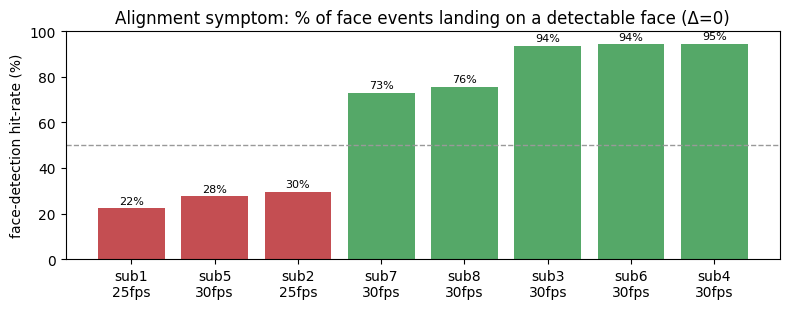

In [4]:
# Lightweight per-subject context, cached so later cells don't re-read EEG/xlsx.
# (Deliberately independent of the Stage-1 activation cache: this whole section
#  reads the video live, so it runs even with REBUILD_CACHE = False.)
_CTX = {}

def subject_context(sub):
    "Cached alignment context for a subject (no video capture handle)."
    if sub not in _CTX:
        raw = eu.load_eeg(sub)
        sf = raw.info["sfreq"]
        _CTX[sub] = dict(
            t1=eu.get_t1(sub, raw),
            sf=sf,
            eeg_dur=raw.n_times / sf,
            events=eu.get_face_events(raw),               # [(onset_s, "UP"|"IN")]
            emb_corr=eu.regressor_embedded_corr(raw),     # rebuilt vs stored regressor
        )
    return _CTX[sub]


def probe_faces(sub, deltas, sample=None, min_conf=None):
    """Detector hit-rate for a subject at each time offset in `deltas`.

    For every sampled in-range face event, shift its video time by `delta`, grab
    that frame, and run the (upright+180°) Haar detector. Returns
    (deltas, hitrate_per_delta, n_events_used). Opens the video once.

    `sample`: if given, use this many events evenly spread across the video
    (keeps offset sweeps fast); None = every in-range event.
    """
    ctx = subject_context(sub)
    t1 = ctx["t1"]
    cap, fps, nf = cu.open_video(sub)
    dur = nf / fps
    try:
        base = [(o, l) for (o, l) in ctx["events"] if 0 <= o - t1 < dur]
        if sample is not None and len(base) > sample:
            sel = np.linspace(0, len(base) - 1, sample).astype(int)
            base = [base[i] for i in sel]
        rates = []
        for d in np.atleast_1d(deltas).astype(float):
            hits = tested = 0
            for onset, _label in base:
                tv = onset - t1 + d
                if not (0 <= tv < dur):
                    continue
                frame = cu.grab_frame(cap, tv, fps)
                if frame is None:
                    continue
                bbox = cu.detect_face_bbox(frame, min_confidence=min_conf,
                                           return_confidence=False)
                tested += 1
                hits += bbox is not None
            rates.append(hits / tested if tested else np.nan)
        return np.atleast_1d(deltas).astype(float), np.array(rates), len(base)
    finally:
        cap.release()


DIAG_SUBJECTS = list(SUBJECTS)          # subjects to diagnose (e.g. [1, 3] to go faster)

rows = []
print("Scanning face-event alignment per subject (detector run unthresholded)...\n")
for sub in DIAG_SUBJECTS:
    ctx = subject_context(sub)
    t1, events = ctx["t1"], ctx["events"]
    _cap, fps, nf = cu.open_video(sub); _cap.release()
    dur = nf / fps
    tv = np.array([o - t1 for o, _ in events])
    n_before = int((tv < 0).sum())
    n_after  = int((tv >= dur).sum())
    n_in     = int(((tv >= 0) & (tv < dur)).sum())
    _, rate, n_used = probe_faces(sub, [0.0])            # hit-rate at the real mapping
    rows.append(dict(sub=sub, t1=t1, fps=fps, dur=dur, eeg_dur=ctx["eeg_dur"],
                     n=len(events), n_in=n_in, n_before=n_before, n_after=n_after,
                     first_tv=float(tv.min()), last_tv=float(tv.max()),
                     hit=rate[0], n_used=n_used))

hdr = (f"{'sub':>3} {'t1(s)':>7} {'fps':>5} {'vid(s)':>7} {'eeg(s)':>7} "
       f"{'ev':>3} {'in':>3} {'<0':>3} {'>dur':>4} {'1st_tv':>7} {'last_tv':>8} {'hit%':>6}")
print(hdr); print("-" * len(hdr))
for r in sorted(rows, key=lambda r: r["hit"]):
    print(f"{r['sub']:>3} {r['t1']:>7.2f} {r['fps']:>5.1f} {r['dur']:>7.1f} "
          f"{r['eeg_dur']:>7.1f} {r['n']:>3} {r['n_in']:>3} {r['n_before']:>3} "
          f"{r['n_after']:>4} {r['first_tv']:>7.1f} {r['last_tv']:>8.1f} "
          f"{100*r['hit']:>5.0f}%")

# bar chart of the headline hit-rate, worst -> best
order = sorted(rows, key=lambda r: r["hit"])
fig, ax = plt.subplots(figsize=(8, 3.2))
labels = [f"sub{r['sub']}\n{r['fps']:.0f}fps" for r in order]
bars = ax.bar(labels, [100 * r["hit"] for r in order],
              color=["#C44E52" if r["hit"] < 0.5 else "#55A868" for r in order])
ax.set_ylabel("face-detection hit-rate (%)")
ax.set_title("Alignment symptom: % of face events landing on a detectable face (Δ=0)")
ax.axhline(50, color="0.6", ls="--", lw=1)
ax.set_ylim(0, 100)
for b, r in zip(bars, order):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 2,
            f"{100*r['hit']:.0f}%", ha="center", fontsize=8)
fig.tight_layout(); plt.show()

## 2. Are the face *events* read correctly? (rule out suspect 3 at the source)

Before blaming the video mapping, confirm the events themselves are read faithfully from
`RmIaf_mobileface`. The authors stored their own pre-convolved **`FaceInversion`** channel in the
file; `eeg_utils.regressor_embedded_corr` rebuilds the regressor from the `UP`/`IN` annotations we
read and correlates it against that stored channel. A correlation near **1.0** means our event
onsets and labels match what the authors intended — so any misalignment is downstream, in the
**EEG→video** step, not in how we parsed the events. A low correlation for a specific subject would
instead point the finger at the annotations themselves.

**Columns in the table below:**

- **`sub`** — subject number (1–8).
- **`UP`** — number of **upright** face events read from this subject's `UP`/`IN` annotations.
- **`IN`** — number of **inverted** (upside-down) face events.
- **`events`** — total face events for the subject (`UP + IN`).
- **`regressor_corr`** — Pearson correlation between the face-inversion regressor we *rebuild* from
  the `UP`/`IN` onsets and the authors' *stored* pre-convolved `FaceInversion` channel. **≈ 1.000**
  means our parsing reproduces theirs exactly, so the events are not the source of any misalignment.
- A trailing **`<-- check`** flag is printed whenever `regressor_corr` is `NaN` or `≤ 0.9`, i.e. the
  rebuilt regressor does *not* match the stored channel for that subject and the annotations deserve
  a closer look.


In [5]:
print(f"{'sub':>3} {'UP':>4} {'IN':>4} {'events':>7} {'regressor_corr':>15}")
print("-" * 36)
for sub in DIAG_SUBJECTS:
    ctx = subject_context(sub)
    labels = [l for _, l in ctx["events"]]
    n_up, n_in = labels.count("UP"), labels.count("IN")
    c = ctx["emb_corr"]
    flag = "" if (c == c and c > 0.9) else "   <-- check"   # c==c filters NaN
    print(f"{sub:>3} {n_up:>4} {n_in:>4} {len(labels):>7} {c:>15.3f}{flag}")

print("\ncorr≈1 => events/labels are read faithfully; misalignment is in the EEG→video mapping.")

sub   UP   IN  events  regressor_corr
------------------------------------
  1   24   22      46           1.000
  2   32   29      61           1.000
  3   32   32      64           1.000
  4   44   30      74           1.000
  5   44   34      78           1.000
  6   52   52     104           1.000
  7   40   40      80           1.000
  8   70   72     142           1.000

corr≈1 => events/labels are read faithfully; misalignment is in the EEG→video mapping.


## 3. The video-start trigger `T 1` (the constant-offset suspect)

Everything hinges on `t1`. `eeg_utils.get_t1` reads it from `Triggers.xlsx` (authoritative, present
for every subject) but also cross-checks any `T 1` annotation kept inside the `.set` file and warns
on a mismatch > 0.1 s. A wrong or mis-picked `T 1` shifts **every** event by the same amount, which
would look like a uniformly low hit-rate that a single constant offset (§4) can fully repair.

Here we lay the two `T 1` sources side by side, and show how many `T 1` rows each `Triggers.xlsx`
contains (the sheet has both a video-**start** and a video-**end** `T 1`; `video_start_sample` takes
the earliest — if that heuristic ever grabbed the wrong row, it would surface as a large xlsx-vs-set
gap here).

**Columns in the table below:**

- **`sub`** — subject number (1–8).
- **`xlsx_T1_smp`** — the **raw EEG sample** taken straight from column C of `Triggers.xlsx` (the
  earliest `T 1` row). This is the exact integer sitting in the spreadsheet, so it can be eyeballed
  back against the sheet cell-for-cell. `video_start_sample` returns the *minimum* over the `T 1`
  rows, so this is the video-**start** sample.
- **`sfreq`** — the EEG sample rate in Hz (500 for this dataset), used to convert samples → seconds.
- **`xlsx_T1(s)`** — `xlsx_T1_smp / sfreq`: the video-start time in EEG **seconds**. This is exactly
  the `t1` that `eu.get_t1` returns and that the whole pipeline uses as `t_video = onset − t1`.
- **`set_T1(s)`** — the earliest `T 1` **annotation** time (seconds) stored *inside* the `.set` file,
  as an independent cross-check. Shown as **`n/a`** when the `.set` carries no `T 1` annotation.
- **`diff(s)`** — `set_T1 − xlsx_T1`. Should be ≈ 0 when the two sources agree; **`--`** when there is
  no `.set` value to compare against.
- **`#T1_xlsx`** — how many `T 1` rows exist in that subject's `Triggers.xlsx` (typically 2: video
  start + video end). A count ≠ 2 is a hint the sheet layout differs and the start-row heuristic is
  worth double-checking.
- A trailing **`<-- mismatch`** flag is printed when the `.set` `T 1` is missing (`n/a`) **or** differs
  from the xlsx value by more than 0.1 s — i.e. `t1` cannot be independently confirmed for that
  subject.


In [6]:
print(f"{'sub':>3} {'xlsx_T1_smp':>11} {'sfreq':>6} {'xlsx_T1(s)':>11} "
      f"{'set_T1(s)':>10} {'diff(s)':>8} {'#T1_xlsx':>8}")
print("-" * 63)
for sub in DIAG_SUBJECTS:
    ctx = subject_context(sub)
    sf = ctx["sf"]
    # Raw EEG sample from Triggers.xlsx column C (earliest 'T 1' row) -- this is
    # the exact number sitting in the spreadsheet, to eyeball back manually.
    xlsx_smp = eu.video_start_sample(sub)
    xlsx_t1  = xlsx_smp / sf                              # == eu.get_t1(sub, raw)
    # all T1 rows in the xlsx (start + end), and the .set annotation T1s
    _rows = eu._read_xlsx_sheet(eu.DATA_ROOT / f"sub{sub}" / "Triggers.xlsx")
    n_t1 = sum(str(r.get("B", "")).strip().upper().replace(" ", "") == "T1"
               and "C" in r for r in _rows)
    raw = eu.load_eeg(sub)
    set_t1s = [float(o) for o, d in zip(raw.annotations.onset, raw.annotations.description)
               if d.strip().upper().replace(" ", "") == "T1"]
    set_t1 = min(set_t1s) if set_t1s else float("nan")
    diff = (set_t1 - xlsx_t1) if set_t1s else float("nan")
    flag = "" if (diff == diff and abs(diff) <= 0.1) else "   <-- mismatch"
    set_str = f"{set_t1:>10.2f}" if set_t1s else f"{'n/a':>10}"
    diff_str = f"{diff:>8.2f}" if diff == diff else f"{'--':>8}"
    print(f"{sub:>3} {xlsx_smp:>11d} {sf:>6.0f} {xlsx_t1:>11.2f} "
          f"{set_str} {diff_str} {n_t1:>8}{flag}")


sub xlsx_T1_smp  sfreq  xlsx_T1(s)  set_T1(s)  diff(s) #T1_xlsx
---------------------------------------------------------------
  1        9282    500       18.56        n/a       --        2   <-- mismatch
  2        2676    500        5.35        n/a       --        2   <-- mismatch
  3       15287    500       30.57      30.57    -0.00        2
  4        5791    500       11.58      11.58    -0.00        1
  5        5751    500       11.50        n/a       --        2   <-- mismatch
  6        3205    500        6.41       6.41    -0.00        2
  7        5392    500       10.78        n/a       --        2   <-- mismatch
  8        8787    500       17.57        n/a       --        2   <-- mismatch


## 4. Does a constant time-shift recover the faces?

For each subject we add a range of extra offsets **Δ** to the video-time
mapping (`t_video = onset − t1 + Δ`) and recompute the detector hit-rate at each Δ. The shape of the
curve tells us *which* hypothesis is true:

- **Sharp peak at Δ ≈ 0** → the mapping is correct (this should be sub3).
- **Sharp peak at Δ ≠ 0** → a pure **constant offset**: `t1` is off by that many seconds and the fix
  is trivial (correct `T 1`).
- **No peak — low and flat everywhere** → *not* a constant offset. Either the error **drifts** across
  the video (a clock-rate / fps mismatch, tested in §5) or the events are in a different time base
  entirely for that subject.

The sweep samples a spread of events per subject (`OFFSET_SAMPLE`) to stay fast; widen `OFFSET_GRID`
or raise the sample count for a finer picture once you know where to look.

  sub1: peak 44% at Δ=+2.0s (Δ=0 -> 24%, n=25)
  sub2: peak 44% at Δ=-8.0s (Δ=0 -> 32%, n=25)
  sub3: peak 100% at Δ=+1.0s (Δ=0 -> 96%, n=25)
  sub4: peak 96% at Δ=-1.0s (Δ=0 -> 96%, n=25)
  sub5: peak 48% at Δ=-8.0s (Δ=0 -> 24%, n=25)
  sub6: peak 100% at Δ=+0.0s (Δ=0 -> 100%, n=25)
  sub7: peak 84% at Δ=-8.0s (Δ=0 -> 60%, n=25)
  sub8: peak 92% at Δ=-7.0s (Δ=0 -> 88%, n=25)


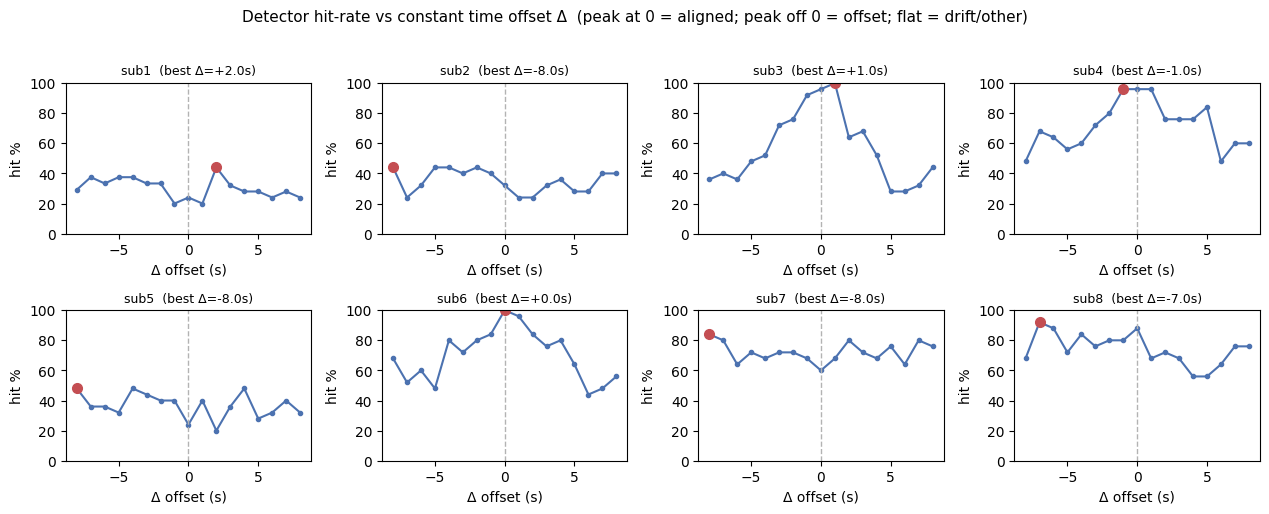

In [7]:
OFFSET_GRID   = np.arange(-8.0, 8.01, 1.0)   # seconds of extra shift to test
OFFSET_SAMPLE = 25                            # events sampled per subject (speed)

sweeps = {}
for sub in DIAG_SUBJECTS:
    d, rate, n_used = probe_faces(sub, OFFSET_GRID, sample=OFFSET_SAMPLE)
    sweeps[sub] = (d, rate)
    best = int(np.nanargmax(rate))
    print(f"  sub{sub}: peak {100*rate[best]:.0f}% at Δ={d[best]:+.1f}s "
          f"(Δ=0 -> {100*rate[np.where(d == 0)[0][0]]:.0f}%, n={n_used})")

ncol = 4
nrow = int(np.ceil(len(DIAG_SUBJECTS) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.2 * ncol, 2.6 * nrow), squeeze=False)
for ax, sub in zip(axes.ravel(), DIAG_SUBJECTS):
    d, rate = sweeps[sub]
    best = int(np.nanargmax(rate))
    ax.plot(d, 100 * rate, "-o", ms=3, color="#4C72B0")
    ax.axvline(0, color="0.7", ls="--", lw=1)
    ax.plot(d[best], 100 * rate[best], "o", color="#C44E52", ms=7)
    ax.set_title(f"sub{sub}  (best Δ={d[best]:+.1f}s)", fontsize=9)
    ax.set_ylim(0, 100); ax.set_xlabel("Δ offset (s)"); ax.set_ylabel("hit %")
for ax in axes.ravel()[len(DIAG_SUBJECTS):]:
    ax.axis("off")
fig.suptitle("Detector hit-rate vs constant time offset Δ  "
             "(peak at 0 = aligned; peak off 0 = offset; flat = drift/other)", fontsize=11)
fig.tight_layout(rect=(0, 0, 1, 0.96)); plt.show()

## 5. Is the error *drifting* across the video?
If §4 shows no clean constant-offset peak, the next suspect is a **clock-rate mismatch**: the EEG
clock and the video clock run at slightly different speeds, so the correct offset is small at the
start of the recording and grows (or shrinks) toward the end. We test it directly: split each
subject's in-range events into an **early half** and a **late half** and find the best offset within
each. If the two best offsets differ substantially — and consistently in sign across subjects — the
error is drifting, not constant, and no single `t1` can fix it (the mapping needs a slope, not just
an intercept).

The right-hand panel overlays the early- vs late-half sweep for `FOCUS_SUB` so you can see the peak
move.

sub  best_early  best_late  drift(s)
------------------------------------
  1        +2.0       +2.0      +0.0
  2        -4.0       -3.0      +1.0
  3        +0.0       -1.0      -1.0
  4        -1.0       +0.0      +1.0
  5        -8.0       -6.0      +2.0
  6        -1.0       +0.0      +1.0
  7        -4.0       -2.0      +2.0
  8        -7.0       -8.0      -1.0


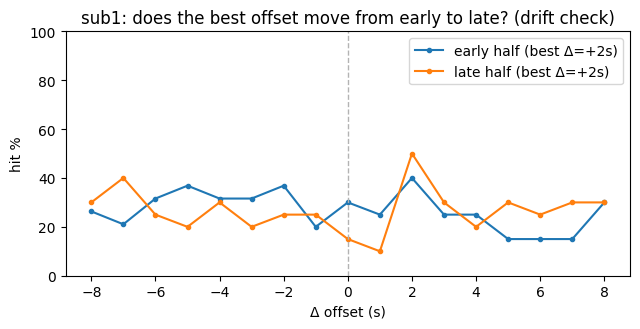

In [8]:
def half_sweep(sub, deltas, which, sample=20):
    "Offset sweep over only the early or late half of a subject's in-range events."
    ctx = subject_context(sub); t1 = ctx["t1"]
    cap, fps, nf = cu.open_video(sub); dur = nf / fps
    try:
        base = [(o, l) for (o, l) in ctx["events"] if 0 <= o - t1 < dur]
        half = base[: len(base) // 2] if which == "early" else base[len(base) // 2:]
        if len(half) > sample:
            sel = np.linspace(0, len(half) - 1, sample).astype(int)
            half = [half[i] for i in sel]
        rates = []
        for d in np.atleast_1d(deltas).astype(float):
            hits = tested = 0
            for onset, _ in half:
                tv = onset - t1 + d
                if not (0 <= tv < dur):
                    continue
                fr = cu.grab_frame(cap, tv, fps)
                if fr is None:
                    continue
                tested += 1
                hits += cu.detect_face_bbox(fr, return_confidence=False) is not None
            rates.append(hits / tested if tested else np.nan)
        return np.array(rates)
    finally:
        cap.release()

FOCUS_SUB = 1                          # subject to inspect in detail (a "bad" one)

print(f"{'sub':>3} {'best_early':>11} {'best_late':>10} {'drift(s)':>9}")
print("-" * 36)
skew = {}
for sub in DIAG_SUBJECTS:
    re_ = half_sweep(sub, OFFSET_GRID, "early")
    rl_ = half_sweep(sub, OFFSET_GRID, "late")
    be, bl = OFFSET_GRID[np.nanargmax(re_)], OFFSET_GRID[np.nanargmax(rl_)]
    skew[sub] = (re_, rl_, be, bl)
    print(f"{sub:>3} {be:>+11.1f} {bl:>+10.1f} {bl - be:>+9.1f}")

re_, rl_, be, bl = skew[FOCUS_SUB]
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.plot(OFFSET_GRID, 100 * re_, "-o", ms=3, label=f"early half (best Δ={be:+.0f}s)")
ax.plot(OFFSET_GRID, 100 * rl_, "-o", ms=3, label=f"late half (best Δ={bl:+.0f}s)")
ax.axvline(0, color="0.7", ls="--", lw=1)
ax.set_title(f"sub{FOCUS_SUB}: does the best offset move from early to late? (drift check)")
ax.set_xlabel("Δ offset (s)"); ax.set_ylabel("hit %"); ax.set_ylim(0, 100); ax.legend()
fig.tight_layout(); plt.show()

## 6. Visual confirmation

Numbers are persuasive but faces are conclusive. For one subject we show the actual face-crops the
pipeline grabs at **Δ = 0** (the current, suspect mapping) beside the crops at the **best Δ** found
in §4. If the misalignment is a recoverable offset, the right-hand grid fills with real, correctly
oriented faces where the left-hand grid showed background/no-face. If both grids stay empty, the
problem is not a single shift — corroborating a drift or bad-events diagnosis.

sub3: comparing Δ=0.0s (current mapping) vs Δ=+1.0s (best from §4)


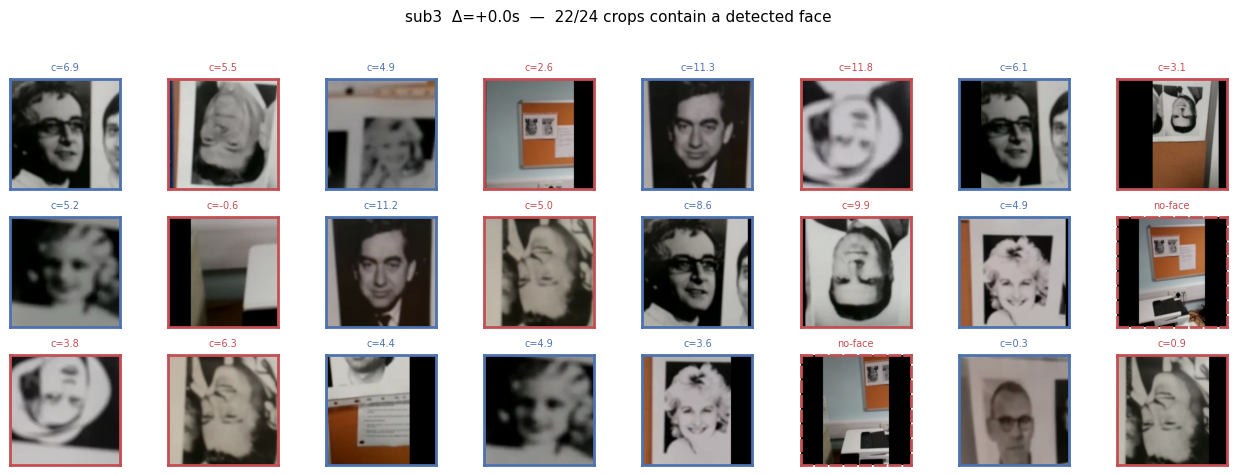

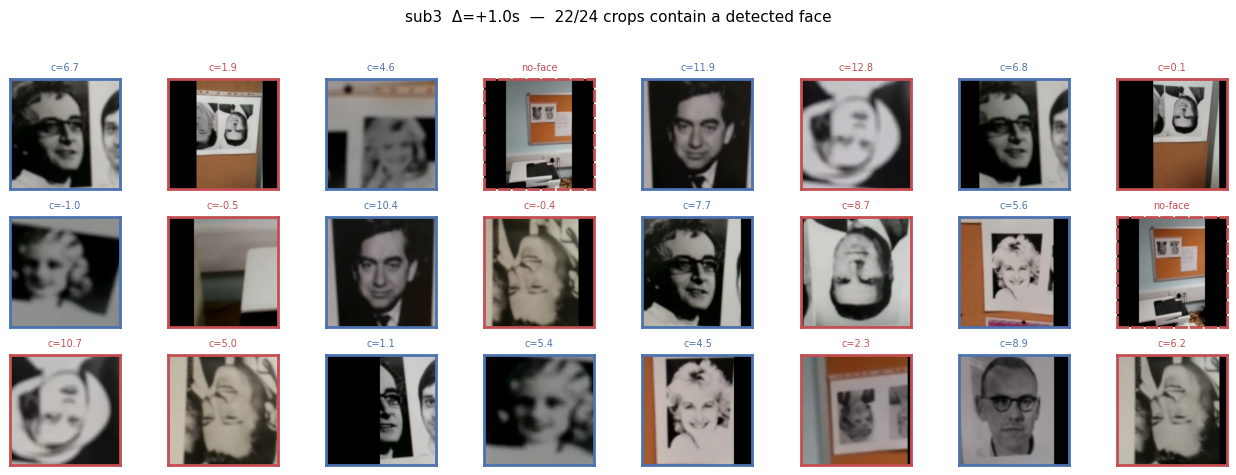

In [9]:
FOCUS_SUB = 3

def show_at_offset(sub, delta, cols=8, cell=1.6, sample=24):
    "Grid of face-crops for a subject with an extra Δ added to the video mapping."
    ctx = subject_context(sub); t1 = ctx["t1"]
    cap, fps, nf = cu.open_video(sub); dur = nf / fps
    frames, labels, confs = [], [], []
    try:
        base = [(o, l) for (o, l) in ctx["events"] if 0 <= o - t1 + delta < dur]
        if len(base) > sample:
            sel = np.linspace(0, len(base) - 1, sample).astype(int)
            base = [base[i] for i in sel]
        for onset, label in base:
            fr = cu.grab_frame(cap, onset - t1 + delta, fps)
            if fr is None:
                continue
            bbox, conf = cu.detect_face_bbox(fr, return_confidence=True)
            frames.append(cu.crop_to_face(fr, bbox)); labels.append(label); confs.append(conf)
    finally:
        cap.release()
    n = len(frames)
    hit = sum(c is not None for c in confs)
    rows = int(np.ceil(n / cols)) or 1
    fig, axes = plt.subplots(rows, cols, figsize=(cols * cell, rows * cell), squeeze=False)
    for ax in axes.ravel():
        ax.axis("off")
    for ax, fr, lab, c in zip(axes.ravel(), frames, labels, confs):
        ax.imshow(fr); ax.axis("on"); ax.set_xticks([]); ax.set_yticks([])
        color = "#C44E52" if lab == "IN" else "#4C72B0"
        for sp in ax.spines.values():
            sp.set_color(color); sp.set_linewidth(2)
            sp.set_linestyle("-" if c is not None else "--")
        ax.set_title("no-face" if c is None else f"c={c:.1f}", color=color, fontsize=7)
    fig.suptitle(f"sub{sub}  Δ={delta:+.1f}s  —  {hit}/{n} crops contain a detected face",
                 fontsize=11)
    fig.tight_layout(rect=(0, 0, 1, 0.96)); plt.show()

best_delta = sweeps[FOCUS_SUB][0][int(np.nanargmax(sweeps[FOCUS_SUB][1]))]
print(f"sub{FOCUS_SUB}: comparing Δ=0.0s (current mapping) vs Δ={best_delta:+.1f}s (best from §4)")
show_at_offset(FOCUS_SUB, 0.0)
show_at_offset(FOCUS_SUB, float(best_delta))

## 7. Diagnosis

*Fill this in from the cells above. The metrics are arranged so each one discriminates a specific
hypothesis:*

| Evidence | Where | Reads as |
|---|---|---|
| Hit-rate at Δ=0, per subject | §1b | The symptom. Ranks subjects; confirms sub3 ≫ subs 1/4/5/7/8. |
| `regressor_corr ≈ 1` | §2 | Events are parsed faithfully → the fault is in the **EEG→video** mapping, not the annotations. |
| `xlsx_T1` vs `set_T1` gap | §3 | A large gap → a **wrong `t1`** → a pure constant offset. |
| Offset sweep peak location | §4 | Peak at Δ≠0 → **constant offset** (fixable via `t1`); flat → not an offset. |
| early-half vs late-half best Δ | §5 | Best offset moving across the video → **clock-rate / fps drift**. |
| Δ=0 vs best-Δ crops | §6 | Visual proof of whether a single shift restores real faces. |

**What a quick pre-check already surfaced (worth confirming at full resolution):**

- The good and bad subjects do **not** share a frame rate — e.g. sub3 (aligned) is **30 fps** while
  sub1 (broken) is **25 fps**. Since `t_video = onset − t1` is computed in *seconds*, fps only sets
  the frame-indexing step, so treat this as a flag to check for a clock-rate story in §5, not a
  proven cause.
- sub1's `t1` **cannot be cross-checked**: its `.set` file carries no `T 1` annotation (§3 shows
  `set_T1 = n/a`), so we trust the xlsx value blind — whereas sub3's xlsx and `.set` `T 1` agree to
  the centisecond. That missing cross-check is exactly where a bad `t1` could hide.
- A coarse offset sweep on sub1 *did* lift the hit-rate well above its Δ=0 value at a small positive
  Δ, which would point back to a **constant `t1` offset** after all — but it was coarse and on few
  events. Run §4/§5 at full resolution across all subjects before committing to a story.

So the two leading hypotheses — a per-subject `t1` offset vs a clock-rate drift — are both still live;
§4 and §5 are built to separate them. Once you know which, the fix follows: correct `t1`, apply a
per-subject linear `t_video = a·(onset − t1) + b` remap, or restrict to the task window as
`ContinuousMobileFace_fileInfo.docx` suggests.

## 8. Interactive scrubber — video ↔ face-inversion regressor

An `ipywidgets` tool to eyeball the T1 registration by hand. Call `explore_alignment(sub)` with the
subject number whose video you want; it puts the **head-cam frame** (left) next to the
**face-inversion regressor** (right, in EEG time), linked by `eeg_t = video_t + t1 + Δ`.

- **`video t (s)`** — scrubs the video. The black cursor on the regressor shows exactly where that
  frame lands in EEG time.
- **`T1 Δ (s)`** — nudges the video-start offset. This is the test: park the cursor on a regressor
  deflection (a labelled face event) and drag `Δ` until a real, correctly-oriented face appears in
  the frame. `Δ = 0` is the current `t1`; the value that lines faces up is your correction.

Regressor sign matches the rest of the notebook: **red stick at +0.5 = IN (inverted)**, **blue stick
at −0.5 = UP (upright)**. Change the subject in the last line (`explore_alignment(3)`). Interactivity
needs a live kernel (`jupyter lab`) with the widgets extension — a static render still shows the first
frame and its regressor context.

In [ ]:
import ipywidgets as widgets
from IPython.display import display


def explore_alignment(sub, t_window=20.0, step=None):
    """Interactive video ↔ face-inversion-regressor scrubber for one subject.

    Left  : the head-cam frame at the chosen video time.
    Right : the face-inversion regressor in EEG time, with a cursor at the EEG
            time this frame maps to (eeg_t = video_t + t1 + Δ) and coloured event
            sticks (red = IN/inverted at +0.5, blue = UP/upright at −0.5).

    Sliders
      video t (s) : scrub the video; the cursor shows where it lands on the EEG.
      T1 Δ (s)    : nudge the video-start offset. Park the cursor on a regressor
                    deflection (a labelled face event) and drag Δ until a real,
                    correctly-oriented face appears in the frame — that Δ is the
                    correction to t1. Δ = 0 is the current t1. The slider steps in
                    whole EEG samples (1/sf s), so keyboard arrows nudge it one
                    sample at a time for sample-precise alignment.

    Both the frame title and the regressor title print the current **EEG sample**
    (`round(eeg_t * sf)`) next to the EEG time, so you can read the exact sample a
    frame maps to and match it against the `Triggers.xlsx` column-C / §3 values.

    The trace is the regressor rebuilt from the UP/IN events at its true ±0.5
    scale; it is identical (corr ≈ 1) to the stored FaceInversion channel, which
    MNE keeps at a near-zero raw scale and so does not plot legibly.
    """
    ctx = subject_context(sub)
    t1, sf, events = ctx["t1"], ctx["sf"], ctx["events"]
    raw = eu.load_eeg(sub)
    reg = eu.build_face_regressors(raw)["face_inversion"]
    t_axis = np.arange(len(reg)) / sf

    # release a video handle from a previous call, then open this subject's
    if getattr(explore_alignment, "_cap", None) is not None:
        explore_alignment._cap.release()
    cap, fps, nf = cu.open_video(sub)
    explore_alignment._cap = cap
    dur = nf / fps
    step = 1.0 / fps if step is None else step
    first_tv = float(np.clip(min(o for o, _ in events) - t1, 0, dur))

    t_slider = widgets.FloatSlider(
        value=first_tv, min=0.0, max=dur, step=step, description="video t (s)",
        continuous_update=True, readout_format=".2f",
        layout=widgets.Layout(width="70%"))
    off_slider = widgets.FloatSlider(
        value=0.0, min=-120.0, max=120.0, step=1.0 / sf, description="T1 Δ (s)",
        continuous_update=True, readout_format=".3f",
        layout=widgets.Layout(width="70%"))
    out = widgets.Output()

    def render(*_):
        with out:
            out.clear_output(wait=True)
            tv, delta = t_slider.value, off_slider.value
            eeg_t = tv + t1 + delta
            eeg_smp = int(round(eeg_t * sf))            # EEG sample this frame maps to
            delta_smp = int(round(delta * sf))          # offset in EEG samples
            frame = cu.grab_frame(cap, tv, fps)
            fig, (axv, axr) = plt.subplots(1, 2, figsize=(12, 4.2),
                                           gridspec_kw={"width_ratios": [1, 1.3]})
            if frame is not None:
                axv.imshow(frame)
            axv.axis("off")
            axv.set_title(f"sub{sub}   video t = {tv:.2f}s   →   "
                          f"EEG t = {eeg_t:.2f}s  (sample {eeg_smp})"
                          + (f"   Δ={delta:+.3f}s / {delta_smp:+d} smp" if delta else ""))

            lo, hi = eeg_t - t_window / 2, eeg_t + t_window / 2
            m = (t_axis >= lo) & (t_axis <= hi)
            axr.plot(t_axis[m], reg[m], color="0.45", lw=1.3, zorder=1)
            axr.axhline(0, color="0.8", lw=0.8)
            axr.axvline(eeg_t, color="k", lw=1.6, zorder=3)
            for o, l in events:
                if lo <= o <= hi:
                    c = "#C44E52" if l == "IN" else "#4C72B0"
                    y = 0.5 if l == "IN" else -0.5
                    axr.plot([o, o], [0, y], color=c, lw=2, zorder=2)
                    axr.plot(o, y, "o", color=c, ms=5, zorder=2)
            i = eeg_smp
            val = float(reg[i]) if 0 <= i < len(reg) else float("nan")
            axr.set_xlim(lo, hi); axr.set_ylim(-0.7, 0.7)
            axr.set_xlabel("EEG time (s)")
            axr.set_ylabel("face-inversion regressor")
            axr.set_title(f"regressor here = {val:+.2f}  @ EEG sample {eeg_smp}\n"
                          "(red = IN/inverted +0.5,  blue = UP/upright −0.5)")
            fig.tight_layout(); plt.show()

    t_slider.observe(render, names="value")
    off_slider.observe(render, names="value")
    display(widgets.VBox([t_slider, off_slider, out]))
    render()


# pick the subject to inspect (1..8)
explore_alignment(1)

## 9. Raw `.set` dump — eyeball the file by hand

A scratch cell to look at what is actually inside one subject's `RmIaf_mobileface.set`, so you can
double-check the `T 1` cross-check (§3) against the source. EEGLAB `.set` files store their triggers
as **annotations** (`onset`, `duration`, `description`) — that's where `T 1`, `UP`, `IN`, etc. live —
so we load the file with MNE and lay those out as a `pandas` DataFrame. Each onset is also converted
back to an **EEG sample**, so it lines up directly with the `Triggers.xlsx` column-C values from §3.
The file's basic geometry (sample rate, length, channel list) is printed above the table.

Set `INSPECT_SUB` to the subject you want. Note that most subjects' `.set` files carry **no `T 1`
annotation at all** (that's why §3 shows `set_T1 = n/a` for them) — in that case the `T1 rows` slice
below will simply be empty, and only the xlsx value in §3 is authoritative.


In [11]:
import pandas as pd

INSPECT_SUB = 3  # Change subject

raw = eu.load_eeg(INSPECT_SUB)
sf = raw.info["sfreq"]

# --- file geometry ---
print(f"sub{INSPECT_SUB}  ->  {eu.eeg_path(INSPECT_SUB)}")
print(f"  sfreq      = {sf:.0f} Hz")
print(f"  n_times    = {raw.n_times} samples  ({raw.n_times / sf:.1f} s)")
print(f"  n_channels = {len(raw.ch_names)}")
print(f"  channels   = {raw.ch_names}")

# --- annotations = the triggers (T 1, UP, IN, ...) as a DataFrame ---
ann = pd.DataFrame({
    "description": [d.strip() for d in raw.annotations.description],
    "onset_s": raw.annotations.onset,
    "duration_s": raw.annotations.duration,
})
ann["sample"] = (ann["onset_s"] * sf).round().astype(int)     # matches Triggers.xlsx col C
ann = ann[["description", "onset_s", "sample", "duration_s"]]

print(f"\n{len(ann)} annotations. Counts by description:")
print(ann["description"].value_counts().to_string())

# T 1 rows only (empty for most subjects -> that's the §3 'n/a')
t1_rows = ann[ann["description"].str.upper().str.replace(" ", "") == "T1"]
print(f"\nT1 rows in this .set ({len(t1_rows)}):")
print(t1_rows.to_string(index=False) if len(t1_rows)
      else "  (none — this .set has no 'T 1' annotation)")

# Whole annotations table (scrollable in Jupyter). Uncomment to force every row
# to render instead of the pandas middle-truncation.
# pd.set_option("display.max_rows", None)
ann

sub3  ->  /Users/ansonliu/Github/vision_proc_networks/data/SUBJECT eeg data/sub3/RmIaf_mobileface.set
  sfreq      = 500 Hz
  n_times    = 255001 samples  (510.0 s)
  n_channels = 68
  channels   = ['Fp1', 'Fz', 'F3', 'F7', 'FT9', 'FC5', 'FC1', 'C3', 'T7', 'TP9', 'CP5', 'CP1', 'Pz', 'P3', 'P7', 'O1', 'Oz', 'O2', 'P4', 'P8', 'TP10', 'CP6', 'CP2', 'Cz', 'C4', 'T8', 'FT10', 'FC6', 'FC2', 'F4', 'F8', 'Fp2', 'AF7', 'AF3', 'AFz', 'F1', 'F5', 'FT7', 'FC3', 'C1', 'C5', 'TP7', 'CP3', 'P1', 'P5', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'P6', 'P2', 'CPz', 'CP4', 'TP8', 'C6', 'C2', 'FC4', 'FT8', 'F6', 'AF8', 'AF4', 'F2', 'Iz', 'x_dir', 'y_dir', 'z_dir', 'FaceInversion']

67 annotations. Counts by description:
description
UP          32
IN          32
boundary     1
M  1         1
T  1         1

T1 rows in this .set (1):
description  onset_s  sample  duration_s
       T  1   30.572   15286       0.002


,description,onset_s,sample,duration_s
0,boundary,0.000,0,0.000
1,M 1,18.764,9382,0.002
2,T 1,30.572,15286,0.002
3,UP,44.034,22017,0.002
4,UP,47.404,23702,0.002
...,...,...,...,...
62,IN,478.884,239442,0.002
63,UP,484.094,242047,0.002
64,UP,486.006,243003,0.002
65,IN,499.016,249508,0.002
